# E2a + E2b — Faster R-CNN Experiments

**E2a:** ResNet50 backbone, NO FPN (single-scale C5, stride 32)
**E2b:** ResNet50 backbone + FPN (Feature Pyramid Network)

## Research question
Is small-detection performance bottleneck architectural (detector) or pipeline (input resolution)?
- E2a vs E1a: two-stage (FRCNN no FPN) vs one-stage (YOLOv5s) — same 640-800px input
- E2b vs E2a: with FPN vs without FPN — isolates contribution of multi-scale features
- E2b vs E1b: two-stage+FPN vs one-stage+high-res — architecture vs pipeline

## Experimental design
- **Backbone frozen** in both E2a and E2b (`trainable_backbone_layers=0`). Clean ablation: only FPN differs.
- AMP enabled. `batch=8` on A100-40GB. 20 epochs.
- E2a anchors: `(8, 16, 32, 64, 128)` adapted for small objects (master plan).
- Resize: aspect-ratio preserved, longest side = 800px.

## Workflow
1. Load configs and E2a results
2. **E2a:** metrics, training curves, per-class AP, sample predictions
3. **E2b:** train on Modal, then load metrics
4. **Compare:** E2a vs E2b, then cross-experiment E1 vs E2

In [1]:
import sys, os, json, yaml
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.append('..')

from src.env import get_device, get_paths, get_env_info, seed_everything
from src.datasets import visdrone_to_coco_json, VISDRONE_CLASSES
from src.metrics import compute_map, extract_best_metrics
from src.visualization import (set_plot_style, draw_bboxes, plot_pr_curve,
                               plot_per_class_ap_heatmap, plot_summary_table)
from src.trainers.frcnn_trainer import FRCNNTrainer

seed_everything(42)
paths = get_paths()
device = get_device()
set_plot_style()

print(json.dumps(get_env_info(), indent=2))
print(f"Data path: {paths['data']}")
print(f"Output path: {paths['output']}")
print(f"Configs path: {paths['configs']}")

{
  "env": "local",
  "device": "mps",
  "cuda_available": false,
  "mps_available": true,
  "torch_version": "2.2.2"
}
Data path: /Users/davide/Desktop/Universita/AI/CV_DL/project/data/VisDrone2019-DET
Output path: /Users/davide/Desktop/Universita/AI/CV_DL/project/results/runs
Configs path: /Users/davide/Desktop/Universita/AI/CV_DL/project/configs


In [2]:
# Load configs
config_dir = paths["configs"]
with open(config_dir / "e2a_frcnn_nofpn.yaml") as f:
    config_e2a = yaml.safe_load(f)
with open(config_dir / "e2b_frcnn_fpn.yaml") as f:
    config_e2b = yaml.safe_load(f)

print("E2a config:")
print(json.dumps(config_e2a, indent=2))
print("\nE2b config:")
print(json.dumps(config_e2b, indent=2))

E2a config:
{
  "experiment": "e2a",
  "backbone": "resnet50",
  "fpn": false,
  "imgsz_max": 800,
  "epochs": 20,
  "batch_size": 8,
  "optimizer": "SGD",
  "lr": 0.005,
  "momentum": 0.9,
  "weight_decay": 0.0001,
  "warmup_epochs": 1,
  "lr_milestones": [
    12,
    16
  ],
  "lr_gamma": 0.1,
  "patience": 7,
  "seed": 42,
  "device": "auto"
}

E2b config:
{
  "experiment": "e2b",
  "backbone": "resnet50",
  "fpn": true,
  "imgsz_max": 800,
  "epochs": 20,
  "batch_size": 8,
  "optimizer": "SGD",
  "lr": 0.005,
  "momentum": 0.9,
  "weight_decay": 0.0001,
  "warmup_epochs": 1,
  "lr_milestones": [
    12,
    16
  ],
  "lr_gamma": 0.1,
  "patience": 7,
  "seed": 42,
  "device": "auto"
}


## E2a — Faster R-CNN no FPN

Results from `results/runs/e2a/` (Modal A100, 20 epochs, batch=8, frozen backbone).

In [3]:
# Load E2a metrics from metrics.jsonl
output_dir = paths["output"]
e2a_dir = output_dir / "e2a"

with open(e2a_dir / "metrics.jsonl") as f:
    e2a_epochs = [json.loads(line) for line in f]

print(f"{'Epoch':<6} {'mAP@0.5':<10} {'mAP@0.5:0.95':<14} {'AP_small':<9} {'AP_med':<9} {'AP_large':<9} {'Loss':<9}")
print("-" * 58)
for e in e2a_epochs:
    print(f"{e['epoch']:<6} {e['val_mAP@0.5']:<10.4f} {e['val_mAP@0.5:0.95']:<14.4f} "
          f"{e['val_AP_small']:<9.4f} {e['val_AP_medium']:<9.4f} {e['val_AP_large']:<9.4f} "
          f"{e['train_total_loss']:<9.4f}")

metrics_e2a = extract_best_metrics(e2a_epochs)
print(f"\nBest epoch: {max(e2a_epochs, key=lambda e: e['val_mAP@0.5'])['epoch']} "
      f"— mAP@0.5 = {metrics_e2a['mAP@0.5']:.4f}")

Epoch  mAP@0.5    mAP@0.5:0.95   AP_small  AP_med    AP_large  Loss     
----------------------------------------------------------
1      0.0207     0.0066         0.0010    0.0100    0.0285    1.1803   
2      0.0375     0.0142         0.0011    0.0213    0.0608    1.1297   
3      0.0451     0.0172         0.0019    0.0270    0.0689    1.1084   
4      0.0536     0.0207         0.0016    0.0321    0.0859    1.0895   
5      0.0552     0.0216         0.0024    0.0322    0.0992    1.0751   
6      0.0599     0.0246         0.0026    0.0376    0.1153    1.0669   
7      0.0647     0.0270         0.0022    0.0413    0.1276    1.0578   
8      0.0711     0.0282         0.0021    0.0452    0.1237    1.0479   
9      0.0692     0.0280         0.0027    0.0445    0.1162    1.0412   
10     0.0717     0.0303         0.0026    0.0459    0.1360    1.0343   
11     0.0716     0.0293         0.0023    0.0445    0.1310    1.0265   
12     0.0722     0.0315         0.0024    0.0480    0.1468    1.

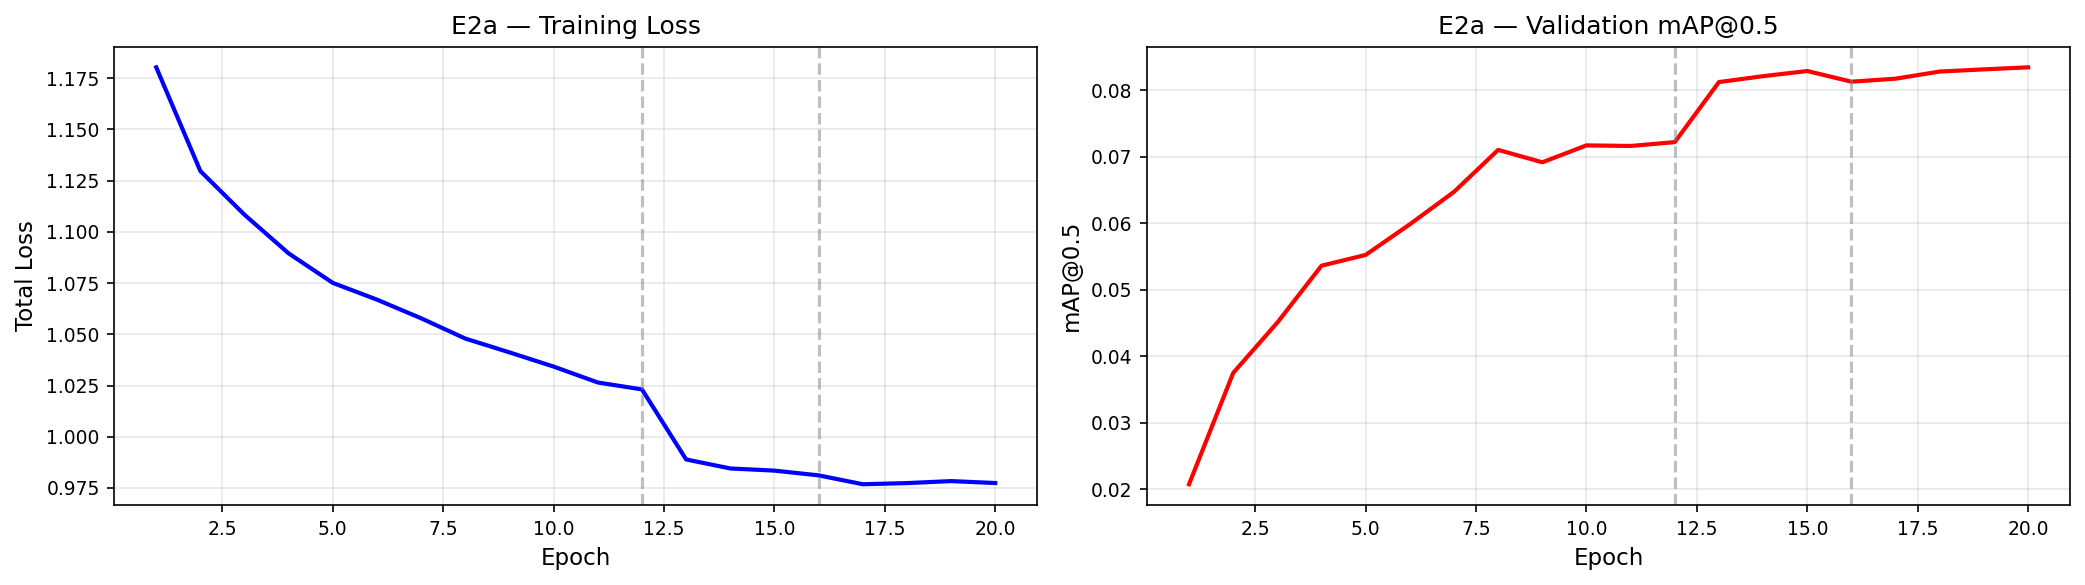

In [4]:
# Training curves — loss and mAP per epoch
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

epochs = [e["epoch"] for e in e2a_epochs]
axes[0].plot(epochs, [e["train_total_loss"] for e in e2a_epochs], "b-", linewidth=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Total Loss"); axes[0].set_title("E2a — Training Loss")
axes[0].grid(True, alpha=0.3)
for ms in [12, 16]:
    axes[0].axvline(ms, color="gray", linestyle="--", alpha=0.5)

axes[1].plot(epochs, [e["val_mAP@0.5"] for e in e2a_epochs], "r-", linewidth=2)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("mAP@0.5"); axes[1].set_title("E2a — Validation mAP@0.5")
axes[1].grid(True, alpha=0.3)
for ms in [12, 16]:
    axes[1].axvline(ms, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(output_dir.parent / "figures" / "e2a_training_curves.png", dpi=150)
plt.show()

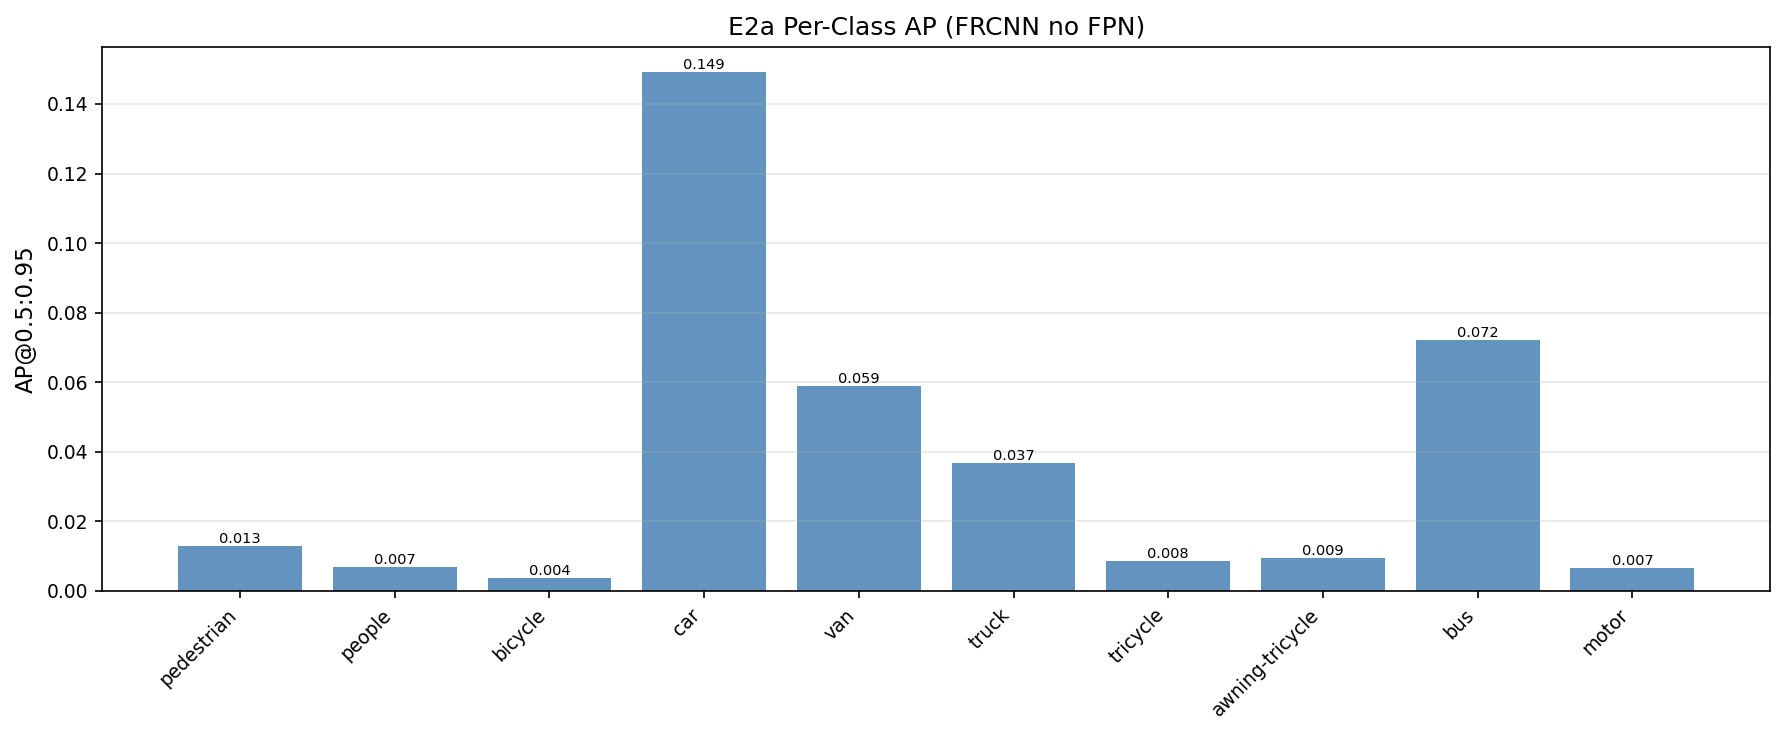

In [5]:
# Per-class AP bar chart
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(VISDRONE_CLASSES))
ax.bar(x, metrics_e2a["AP_per_class"], color="steelblue", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(VISDRONE_CLASSES, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("AP@0.5:0.95")
ax.set_title("E2a Per-Class AP (FRCNN no FPN)")
ax.grid(True, axis="y", alpha=0.3)
for i, v in enumerate(metrics_e2a["AP_per_class"]):
    if v > 0.001:
        ax.annotate(f"{v:.3f}", (i, v), ha="center", va="bottom", fontsize=7)
plt.tight_layout()
plt.savefig(output_dir.parent / "figures" / "e2a_per_class_ap.png", dpi=150)
plt.show()

In [6]:
# E2a per-class AP table
print(f"{'Class':<20s} {'AP@0.5:0.95':<14s}")
print("-" * 34)
for name, ap in zip(VISDRONE_CLASSES, metrics_e2a["AP_per_class"]):
    print(f"{name:<20s} {ap:<14.4f}")
print(f"\n{'mAP@0.5':<20s} {metrics_e2a['mAP@0.5']:<14.4f}")
print(f"{'AP_small':<20s} {metrics_e2a['AP_small']:<14.4f}")
print(f"{'AP_medium':<20s} {metrics_e2a['AP_medium']:<14.4f}")
print(f"{'AP_large':<20s} {metrics_e2a['AP_large']:<14.4f}")

Class                AP@0.5:0.95   
----------------------------------
pedestrian           0.0129        
people               0.0070        
bicycle              0.0037        
car                  0.1491        
van                  0.0591        
truck                0.0368        
tricycle             0.0085        
awning-tricycle      0.0094        
bus                  0.0723        
motor                0.0067        

mAP@0.5              0.0835        
AP_small             0.0034        
AP_medium            0.0571        
AP_large             0.1657        


## E2a — Sample Predictions

Visual comparison of ground truth vs E2a predictions on validation images.

/opt/homebrew/Caskroom/miniconda/base/envs/visdrone/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/visdrone/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded: epoch 20, best_map=0.0832


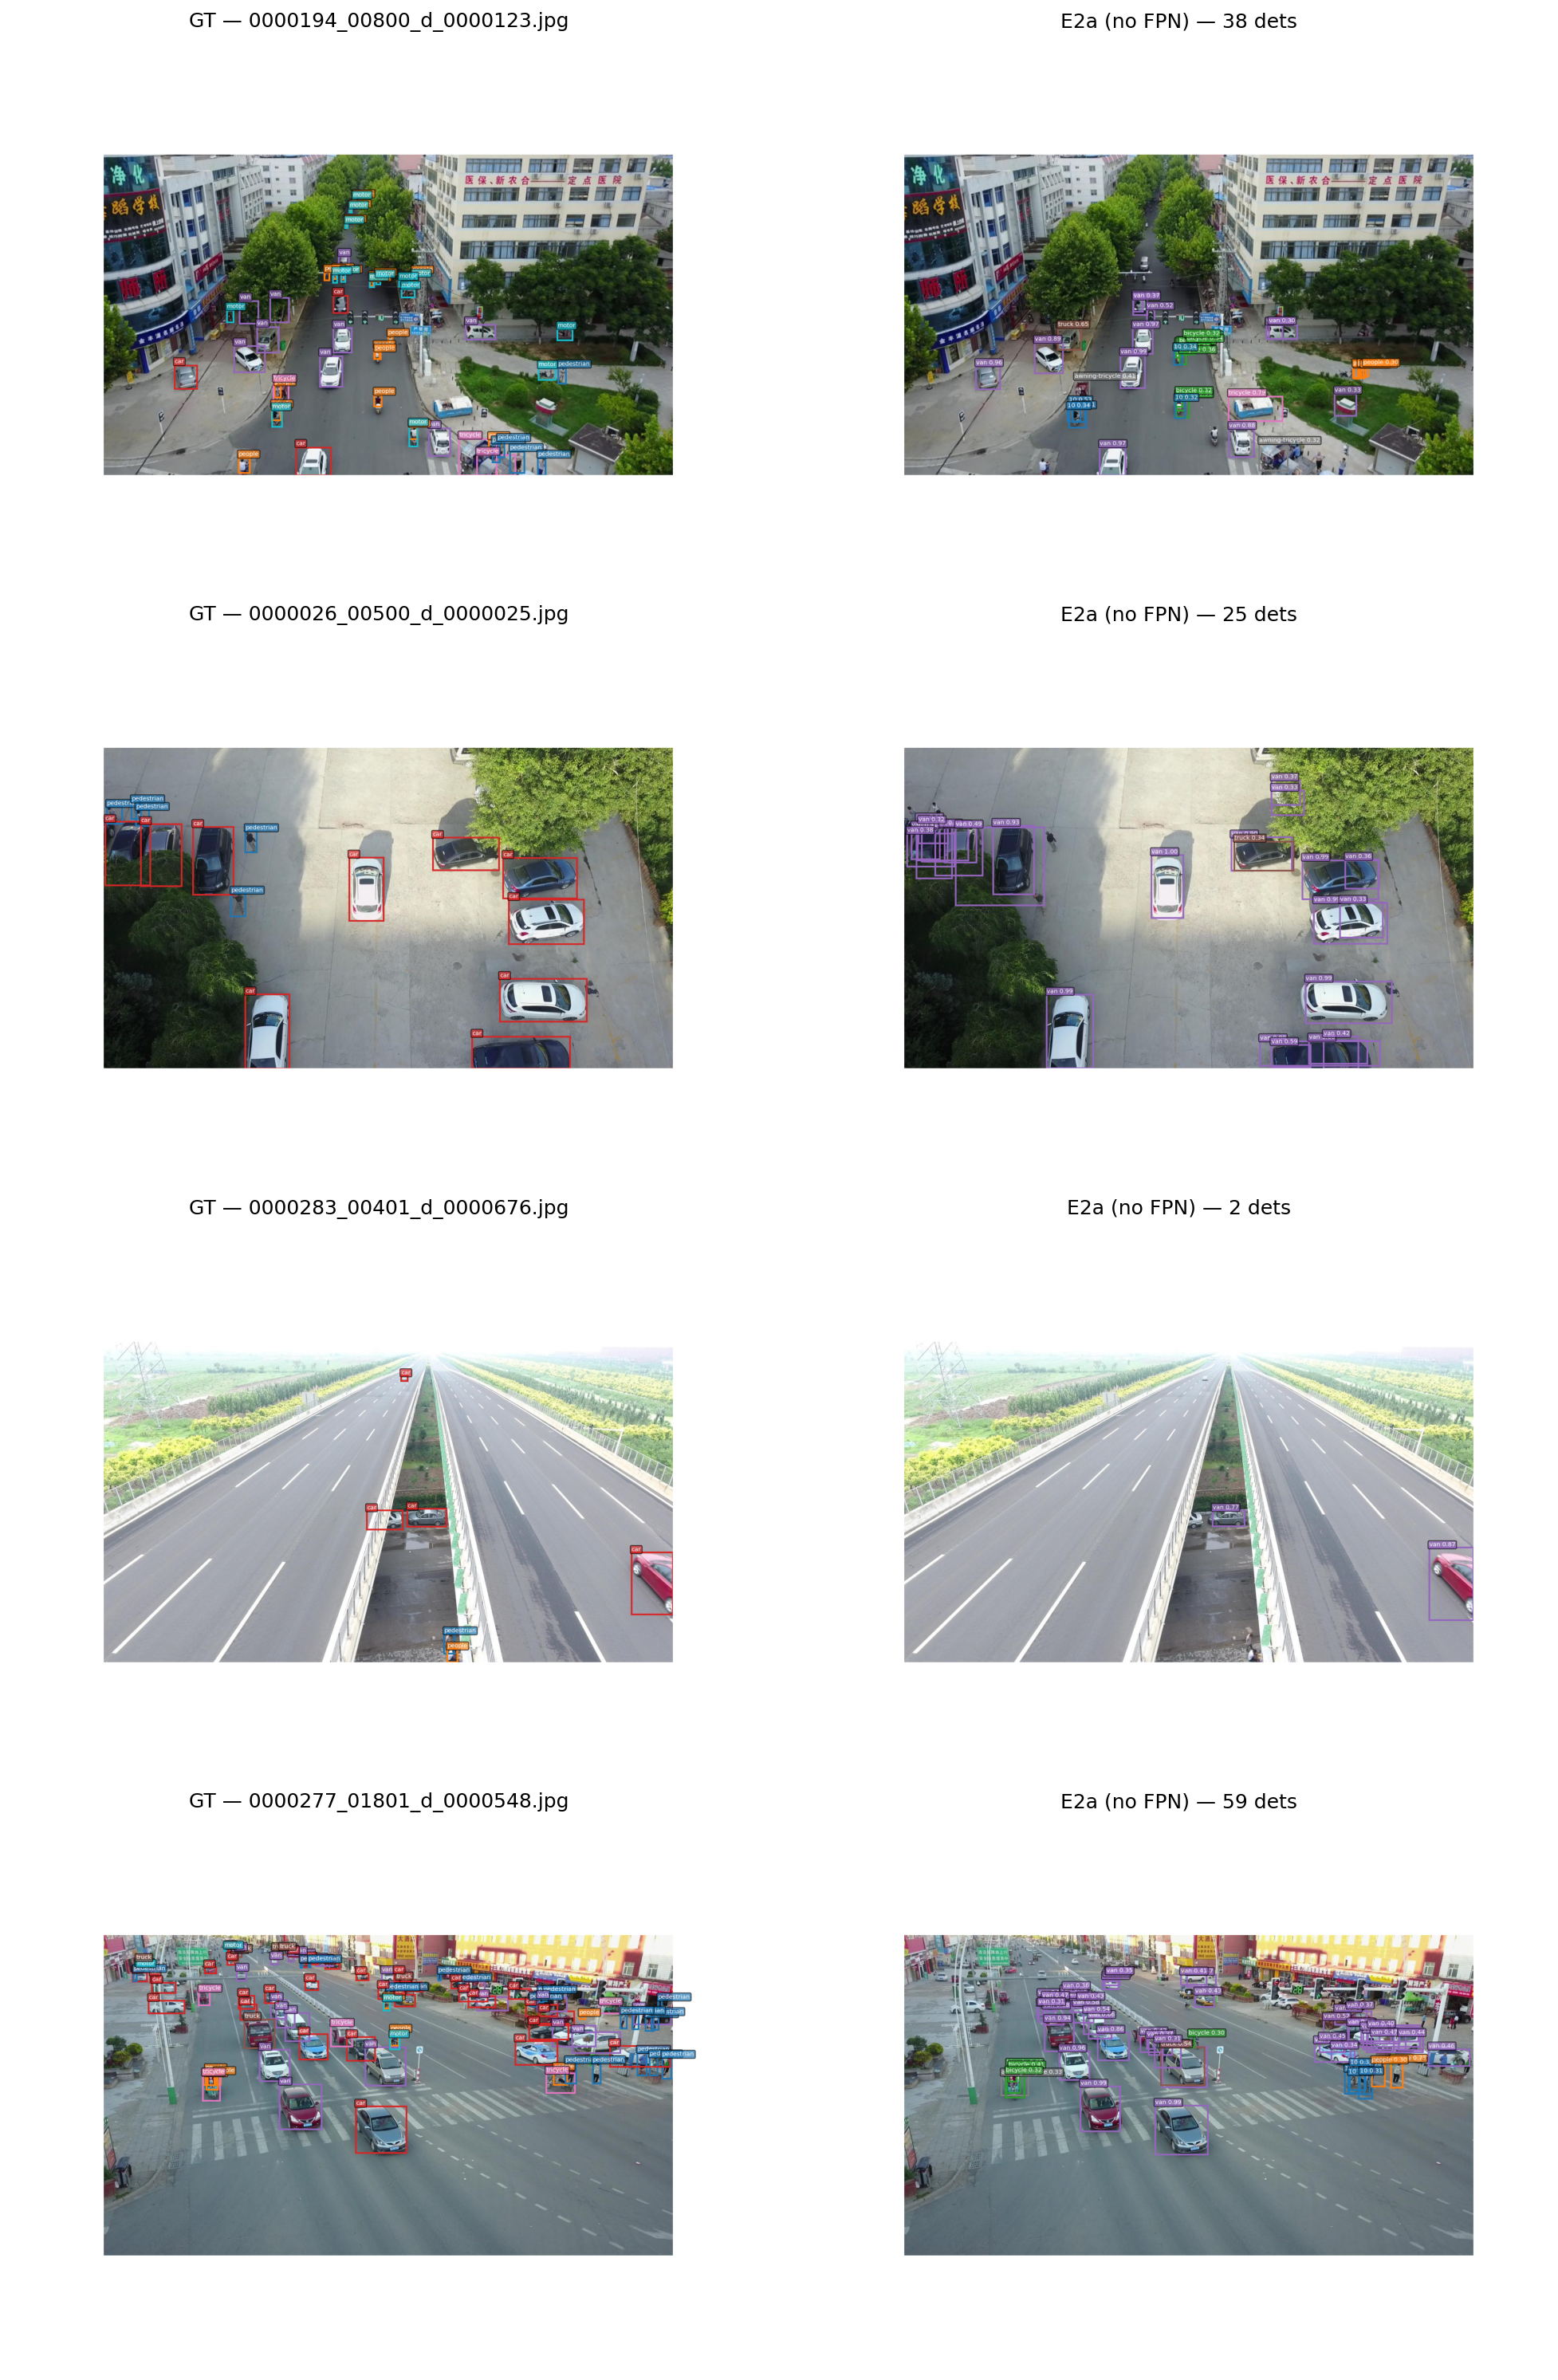

In [7]:
# Sample predictions — E2a model on validation images
import torch
from PIL import Image
from src.augmentations import get_frcnn_val_transforms
from src.trainers.frcnn_trainer import build_frcnn_model

# Build model from config using reusable helper
model = build_frcnn_model(config_e2a)
ckpt = torch.load(e2a_dir / "checkpoints" / "best.pt",
                  map_location=device, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)
print(f"Model loaded: epoch {ckpt['epoch']}, best_map={ckpt['best_map']:.4f}")

# Sample validation images
val_img_dir = paths["data"] / "images" / "val"
val_ann_dir = paths["data"] / "annotations" / "val"
import random
sample_images = sorted(val_img_dir.glob("*.jpg"))
random.seed(42)
samples = random.sample(sample_images, min(4, len(sample_images)))

val_transform = get_frcnn_val_transforms(config_e2a["imgsz_max"])
fig, axes = plt.subplots(len(samples), 2, figsize=(14, 5 * len(samples)))
if len(samples) == 1:
    axes = axes.reshape(1, -1)

for idx, img_path in enumerate(samples):
    img = np.array(Image.open(img_path).convert("RGB"))
    orig_h, orig_w = img.shape[:2]
    imgsz_max = config_e2a["imgsz_max"]
    inv_scale = max(orig_w, orig_h) / imgsz_max

    # Ground truth
    stem = img_path.stem; ann_path = val_ann_dir / f"{stem}.txt"
    gt_boxes, gt_labels = [], []
    if ann_path.exists():
        with open(ann_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cx = float(parts[1]) * orig_w; cy = float(parts[2]) * orig_h
                    bw = float(parts[3]) * orig_w; bh = float(parts[4]) * orig_h
                    gt_boxes.append([cx - bw/2, cy - bh/2, cx + bw/2, cy + bh/2])
                    gt_labels.append(int(parts[0]))
    gt_img = draw_bboxes(img.copy(), gt_boxes, gt_labels)
    axes[idx, 0].imshow(gt_img)
    axes[idx, 0].set_title(f"GT — {img_path.name}")
    axes[idx, 0].axis("off")

    # E2a prediction
    pil_img = Image.open(img_path).convert("RGB")
    img_tensor, _ = val_transform(pil_img, {"boxes": torch.zeros((0, 4)), "labels": torch.zeros(0, dtype=torch.int64)})
    with torch.no_grad():
        output = model([img_tensor.to(device)])[0]
    pred_boxes = output["boxes"].cpu().numpy()
    pred_scores = output["scores"].cpu().numpy()
    pred_labels = output["labels"].cpu().numpy()

    keep = pred_scores > 0.3
    pred_boxes_scaled = pred_boxes[keep] * inv_scale
    pred_img = draw_bboxes(img.copy(), pred_boxes_scaled, pred_labels[keep], pred_scores[keep])
    axes[idx, 1].imshow(pred_img)
    axes[idx, 1].set_title(f"E2a (no FPN) — {keep.sum()} dets")
    axes[idx, 1].axis("off")

plt.tight_layout()
plt.savefig(output_dir.parent / "figures" / "e2a_sample_predictions.png", dpi=150)
plt.show()

## E2b — Faster R-CNN + FPN

Run training on Modal first, then download and re-run cells below.

```bash
conda run -n visdrone modal run modal_app.py::train_experiment --experiment-name e2b
conda run -n visdrone modal volume get visdrone-outputs /runs/e2b results/runs
```

Epoch  mAP@0.5    mAP@0.5:0.95   AP_small  AP_med    AP_large  Loss     
----------------------------------------------------------
1      0.0860     0.0344         0.0175    0.0528    0.0602    1.6711   
2      0.1236     0.0533         0.0306    0.0790    0.0979    1.5325   
3      0.1538     0.0722         0.0395    0.1105    0.1433    1.4353   
4      0.1742     0.0834         0.0472    0.1236    0.1840    1.3771   
5      0.1852     0.0913         0.0491    0.1356    0.1833    1.3332   
6      0.2004     0.1003         0.0560    0.1484    0.2194    1.3012   
7      0.2033     0.1031         0.0583    0.1511    0.2040    1.2702   
8      0.2137     0.1067         0.0616    0.1559    0.2152    1.2456   
9      0.2237     0.1137         0.0651    0.1669    0.2415    1.2274   
10     0.2215     0.1139         0.0638    0.1671    0.2335    1.2073   
11     0.2245     0.1144         0.0672    0.1652    0.2524    1.1931   
12     0.2269     0.1160         0.0649    0.1725    0.2488    1.

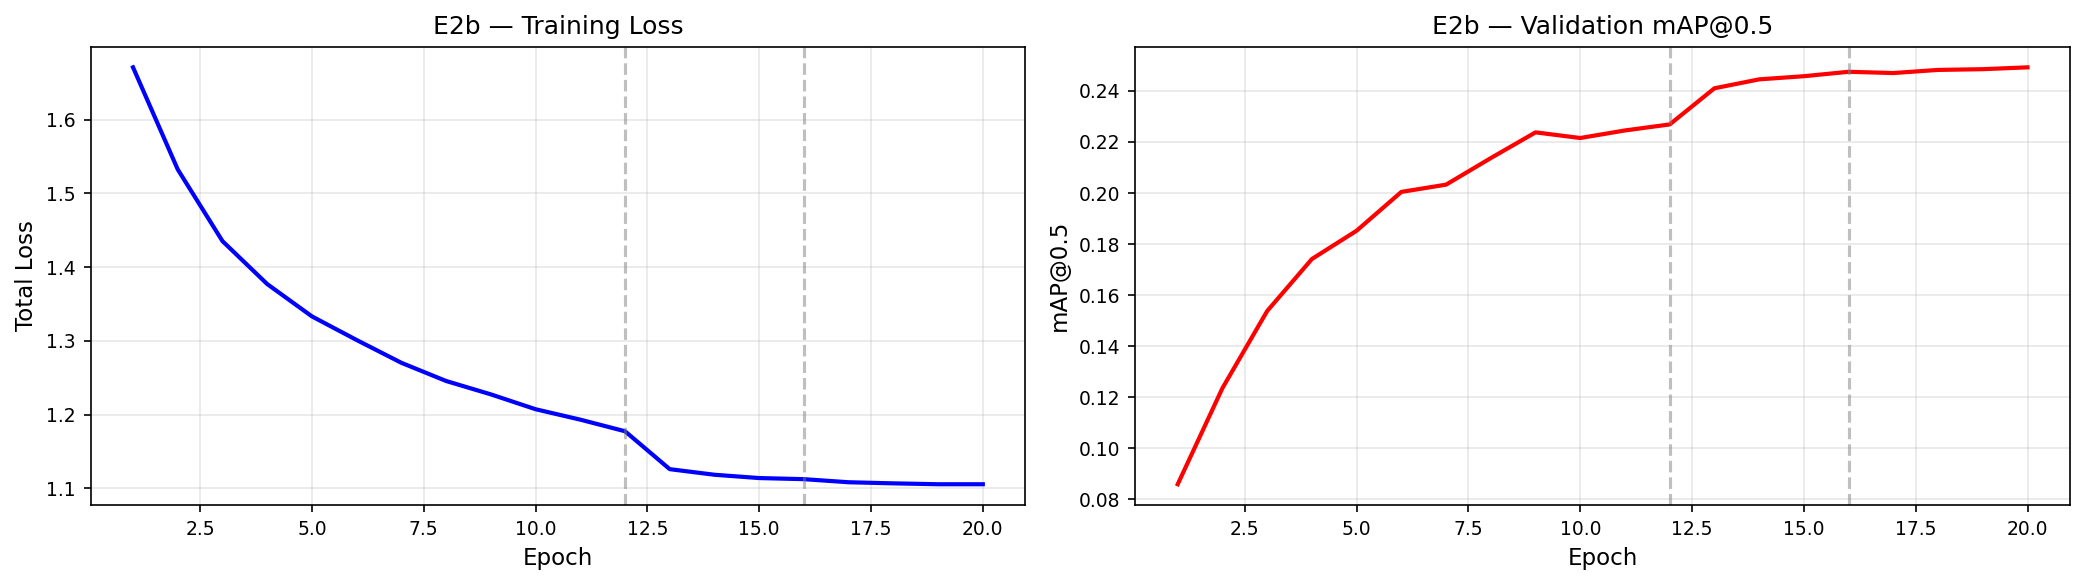

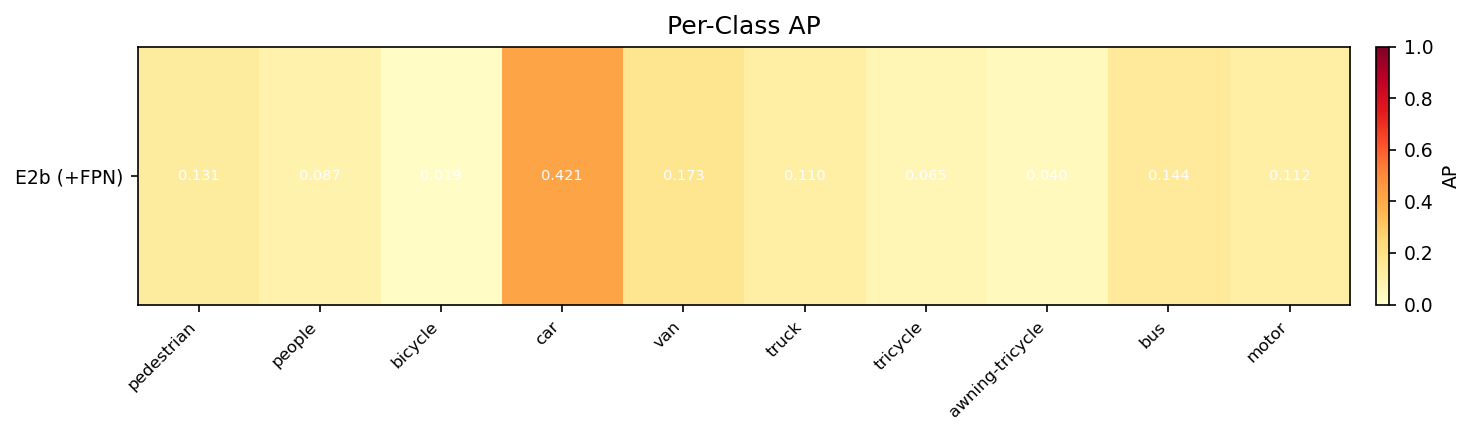

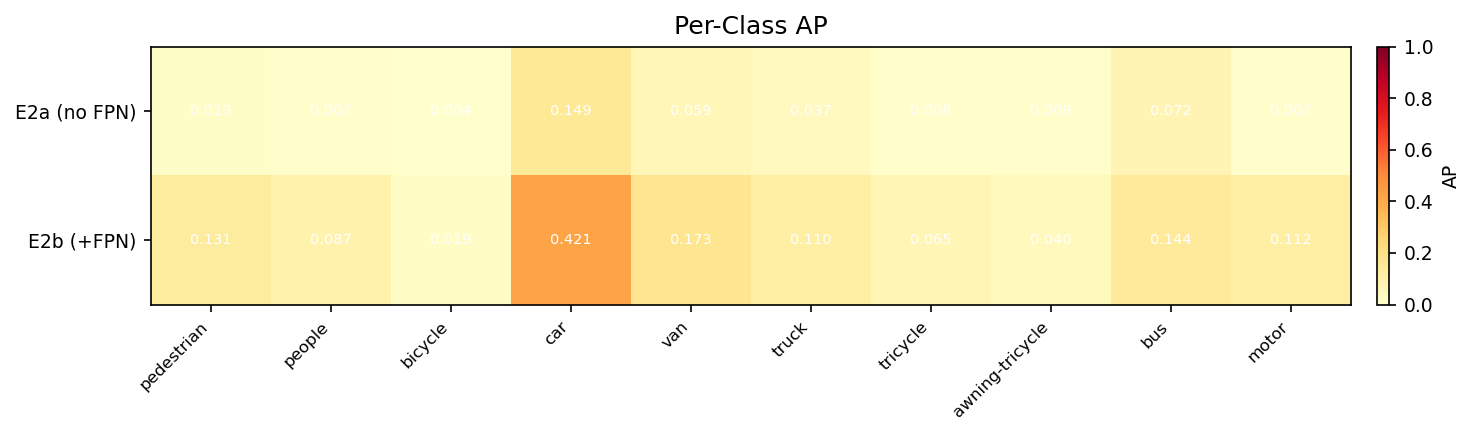

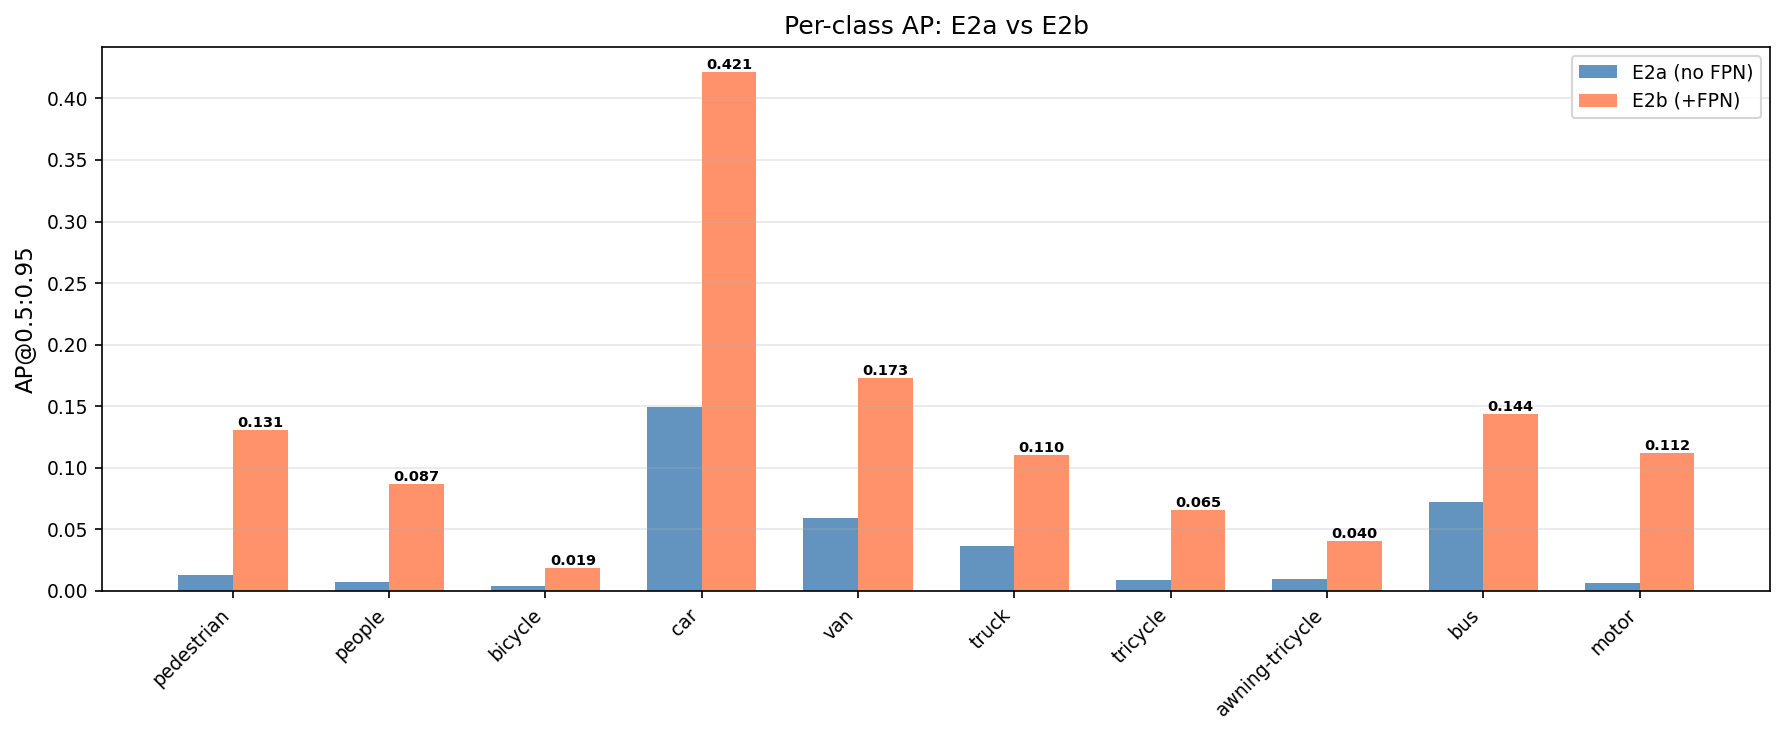


Per-class AP delta (E2b - E2a):
  pedestrian          : +0.1180 ↑
  people              : +0.0799 ↑
  bicycle             : +0.0152 ↑
  car                 : +0.2720 ↑
  van                 : +0.1139 ↑
  truck               : +0.0734 ↑
  tricycle            : +0.0570 ↑
  awning-tricycle     : +0.0310 ↑
  bus                 : +0.0718 ↑
  motor               : +0.1057 ↑


In [8]:
# Load E2b metrics (run after E2b training completes and results downloaded)
e2b_dir = output_dir / "e2b"
if not e2b_dir.exists():
    print("E2b results not found. Train on Modal first:")
    print("  conda run -n visdrone modal run modal_app.py::train_experiment --experiment-name e2b")
    print("  conda run -n visdrone modal volume get visdrone-outputs /runs/e2b results/runs")
else:
    # Load metrics (same format as E2a — reusable parsing)
    with open(e2b_dir / "metrics.jsonl") as f:
        e2b_epochs = [json.loads(line) for line in f]

    print(f"{'Epoch':<6} {'mAP@0.5':<10} {'mAP@0.5:0.95':<14} {'AP_small':<9} {'AP_med':<9} {'AP_large':<9} {'Loss':<9}")
    print("-" * 58)
    for e in e2b_epochs:
        print(f"{e['epoch']:<6} {e['val_mAP@0.5']:<10.4f} {e['val_mAP@0.5:0.95']:<14.4f} "
              f"{e['val_AP_small']:<9.4f} {e['val_AP_medium']:<9.4f} {e['val_AP_large']:<9.4f} {e['train_total_loss']:<9.4f}")

    metrics_e2b = extract_best_metrics(e2b_epochs)
    print(f"\nBest epoch: {max(e2b_epochs, key=lambda e: e['val_mAP@0.5'])['epoch']} "
          f"— mAP@0.5 = {metrics_e2b['mAP@0.5']:.4f}")

    # Training curves — reuse same plot structure as E2a
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    ep = [e["epoch"] for e in e2b_epochs]
    axes[0].plot(ep, [e["train_total_loss"] for e in e2b_epochs], "b-", lw=2)
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Total Loss"); axes[0].set_title("E2b — Training Loss")
    axes[0].grid(True, alpha=0.3)
    for ms in [12, 16]: axes[0].axvline(ms, color="gray", ls="--", alpha=0.5)
    axes[1].plot(ep, [e["val_mAP@0.5"] for e in e2b_epochs], "r-", lw=2)
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("mAP@0.5"); axes[1].set_title("E2b — Validation mAP@0.5")
    axes[1].grid(True, alpha=0.3)
    for ms in [12, 16]: axes[1].axvline(ms, color="gray", ls="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig(output_dir.parent / "figures" / "e2b_training_curves.png", dpi=150)
    plt.show()

    # Per-class AP — uses plot_per_class_ap_heatmap from visualization.py
    plot_per_class_ap_heatmap(
        {"E2b (+FPN)": metrics_e2b["AP_per_class"]},
        save_path=output_dir.parent / "figures" / "e2b_heatmap.png",
        show=True,
    )

    # E2a vs E2b comparison — uses library functions
    ap_dict = {"E2a (no FPN)": metrics_e2a["AP_per_class"], "E2b (+FPN)": metrics_e2b["AP_per_class"]}
    plot_per_class_ap_heatmap(ap_dict,
        save_path=output_dir.parent / "figures" / "e2a_e2b_heatmap.png", show=True)

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(VISDRONE_CLASSES)); width = 0.35
    ax.bar(x - width/2, metrics_e2a["AP_per_class"], width, label="E2a (no FPN)", color="steelblue", alpha=0.85)
    ax.bar(x + width/2, metrics_e2b["AP_per_class"], width, label="E2b (+FPN)", color="coral", alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(VISDRONE_CLASSES, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("AP@0.5:0.95"); ax.set_title("Per-class AP: E2a vs E2b"); ax.legend(); ax.grid(True, axis="y", alpha=0.3)
    for i in range(10):
        v1, v2 = metrics_e2a["AP_per_class"][i], metrics_e2b["AP_per_class"][i]
        best_x = x[i] - width/2 if v1 > v2 else x[i] + width/2
        ax.annotate(f"{max(v1,v2):.3f}", (best_x, max(v1,v2)), ha="center", va="bottom", fontsize=7, fontweight="bold")
    plt.tight_layout(); plt.savefig(output_dir.parent/"figures"/"e2a_e2b_bar_chart.png", dpi=150); plt.show()

    print("\nPer-class AP delta (E2b - E2a):")
    for name, da in zip(VISDRONE_CLASSES, [b-a for a,b in zip(metrics_e2a["AP_per_class"], metrics_e2b["AP_per_class"])]):
        print(f"  {name:20s}: {da:+.4f} {'↑' if da>0 else '↓'}")

## Cross-Experiment: E1 vs E2

All 4 configurations: E1a (YOLO 640), E1b (YOLO 1280), E2a (FRCNN no FPN), E2b (FRCNN + FPN).

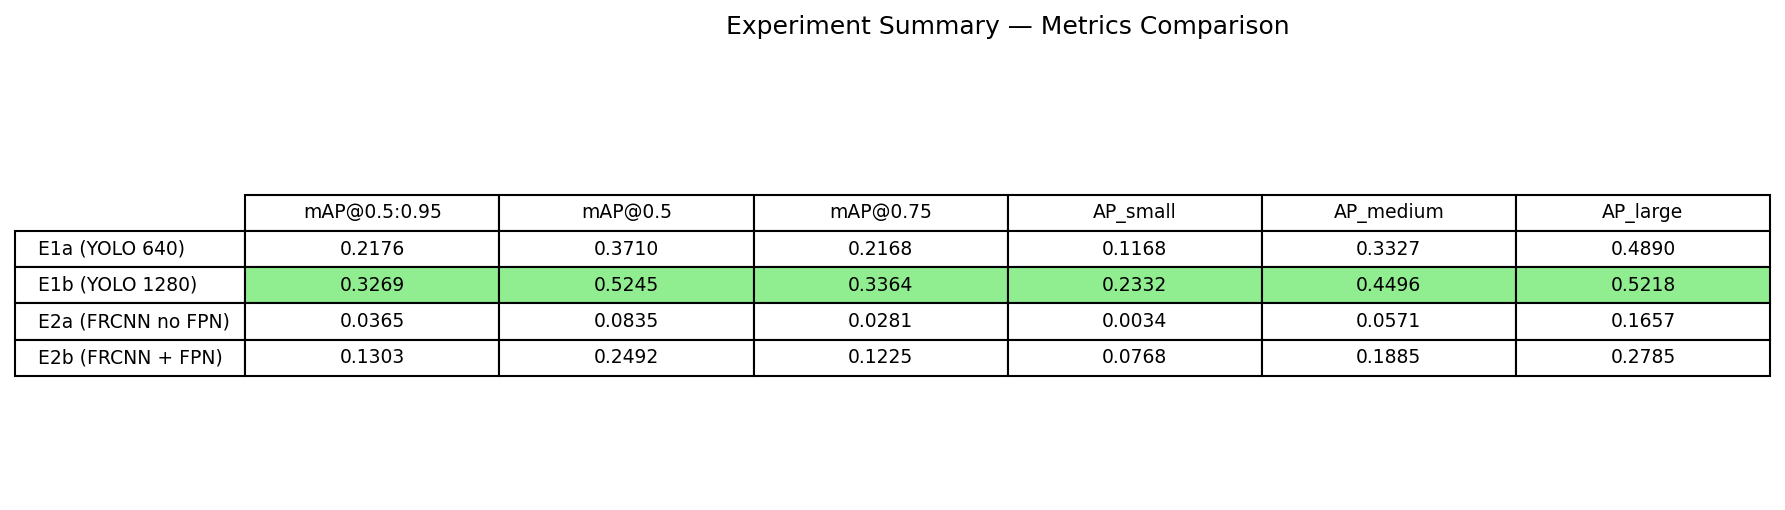

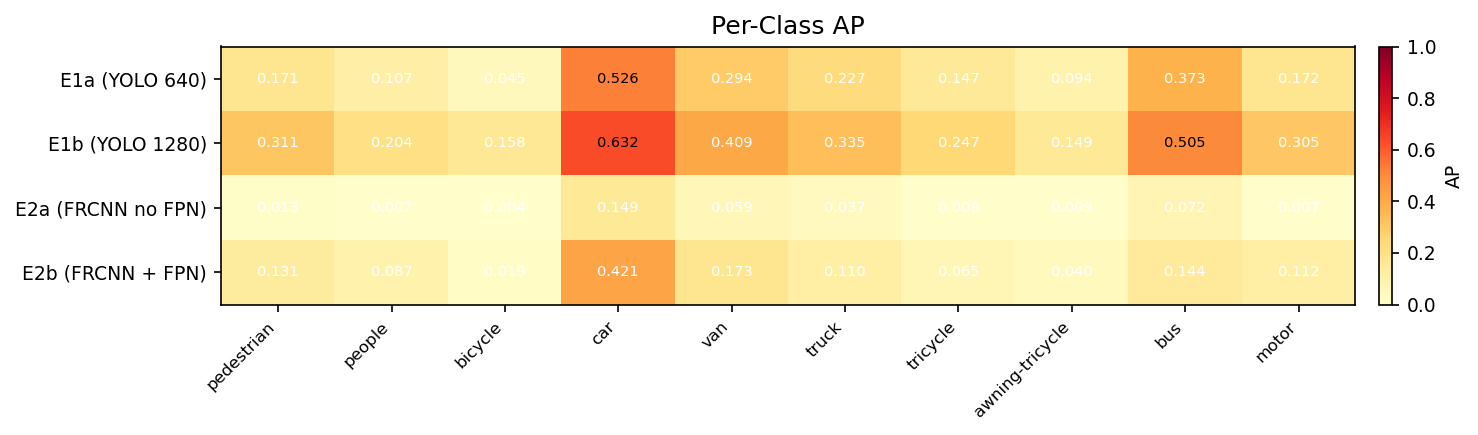

Metric               E1a (YOLO 640)         E1b (YOLO 1280)        E2a (FRCNN no FPN)     E2b (FRCNN + FPN)     
----------------------------------------------------------------------------------------------------------------
mAP@0.5:0.95         0.2176                 0.3269                 0.0365                 0.1303                
mAP@0.5              0.3710                 0.5245                 0.0835                 0.2492                
AP_small             0.1168                 0.2332                 0.0034                 0.0768                
AP_medium            0.3327                 0.4496                 0.0571                 0.1885                
AP_large             0.4890                 0.5218                 0.1657                 0.2785                


In [9]:
# Cross-experiment: E1 vs E2 — uses plot_summary_table + plot_per_class_ap_heatmap
with open(output_dir / "e1a" / "test_metrics.json") as f:
    metrics_e1a = json.load(f)
with open(output_dir / "e1b" / "test_metrics.json") as f:
    metrics_e1b = json.load(f)

cross = {"E1a (YOLO 640)": metrics_e1a, "E1b (YOLO 1280)": metrics_e1b}
try:
    cross["E2a (FRCNN no FPN)"] = metrics_e2a
    cross["E2b (FRCNN + FPN)"] = metrics_e2b
except NameError:
    pass

# Summary table via library
plot_summary_table(cross, save_path=output_dir.parent/"figures"/"e1_e2_cross_table.png", show=True)

# Per-class AP heatmap via library
ap_cross = {n: cross[n]["AP_per_class"] for n in cross if "AP_per_class" in cross[n]}
if len(ap_cross) >= 2:
    plot_per_class_ap_heatmap(ap_cross,
        save_path=output_dir.parent/"figures"/"e1_e2_cross_heatmap.png", show=True)

# Text table for quick reference
print(f"{'Metric':<20}", end="")
for name in cross:
    print(f" {name:<22}", end="")
print()
print("-" * (20 + 23 * len(cross)))
for k in ["mAP@0.5:0.95", "mAP@0.5", "AP_small", "AP_medium", "AP_large"]:
    print(f"{k:<20}", end="")
    for name in cross:
        v = cross[name].get(k, 0)
        print(f" {v:<22.4f}", end="")
    print()
